## Detects pixelated numbers

First I **generated my | data using code from AI** that I prompt, it was tasked to blur images of numbers 0-9 in blocks of 32X32.

The code was changed a bit by me to fit, and it's added in in the project files **('num_gen.py')**. This code outputs the data seen also in the project files **('0_9_blur')** (defualt name fot data output is 'my_dataset')

#### The goal here is to recognise not only numbers from images (too easy), but to classify blured numbers. This has real world use as it can be used to "see" passwords that were blured in a video (for example on youtube).

#### The most popular blur is gaussian blur, but in theory any blur type can be used to train this model, or even another model to classify the blur type and then pass it on to a specialized model.

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [89]:
from IPython.display import Image

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random
import tensorflow_datasets as tfds

In [3]:
from keras.utils import np_utils

In [4]:
import gc

In [5]:
import tensorflow as tf

In [6]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

In [7]:
def training_progress(history):
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Train Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('CNN Model Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Train Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('CNN Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()

  return

## Load and see the data

In [8]:
train_dir = '0_9_blur/train'
test_dir = '0_9_blur/test'

In [9]:
IMG_SIZE = (32, 32)

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',      
    image_size=IMG_SIZE,
    batch_size=32,         
    shuffle=False          
)

Found 4000 files belonging to 10 classes.


In [11]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

Found 1000 files belonging to 10 classes.


In [12]:
print("Converting datasets to NumPy arrays...")
x_train_cnn = np.concatenate([x for x, y in train_ds], axis=0).astype('uint8')
y_train_cnn = np.concatenate([y for x, y in train_ds], axis=0).reshape(-1, 1)

x_test_cnn = np.concatenate([x for x, y in test_ds], axis=0).astype('uint8')
y_test_cnn = np.concatenate([y for x, y in test_ds], axis=0).reshape(-1, 1)

Converting datasets to NumPy arrays...


In [13]:
print("Train size:", x_train_cnn.shape)
print("Test size:", x_test_cnn.shape)
print("Image shape:", x_train_cnn[0].shape)
print("Number of classes:", len(np.unique(y_train_cnn)))

Train size: (4000, 32, 32, 3)
Test size: (1000, 32, 32, 3)
Image shape: (32, 32, 3)
Number of classes: 10


Show data samples:

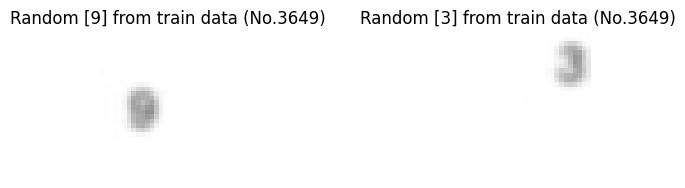

In [14]:
x_train_cnn_size = x_train_cnn.shape[0]
x_test_cnn_size = x_test_cnn.shape[0]
rand_x_train_size = random.randint(1, x_train_cnn_size)
rand_x_test_size = random.randint(1, x_test_cnn_size)

plt.subplot(1,3,1)
plt.imshow(x_train_cnn[rand_x_train_size], cmap='gray')
plt.title(f'Random {y_train_cnn[rand_x_train_size]} from train data (No.{rand_x_train_size})')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(x_test_cnn[rand_x_test_size], cmap='gray')
plt.title(f'Random {y_test_cnn[rand_x_test_size]} from train data (No.{rand_x_train_size})')
plt.axis('off')

plt.show()

## Get the data and model ready and start training

Add a channel dimension and normalize

In [15]:
num_classes = 10
x_train_cnn = x_train_cnn.reshape(x_train_cnn.shape[0], 32, 32, 3).astype('float32')
x_test_cnn = x_test_cnn.reshape(x_test_cnn.shape[0], 32, 32, 3).astype('float32')
print("CNN Train size:", x_train_cnn.shape)
print("CNN Test size:", x_test_cnn.shape)

CNN Train size: (4000, 32, 32, 3)
CNN Test size: (1000, 32, 32, 3)


OneHotEncoding

In [16]:
y_train_cnn_oh = keras.utils.np_utils.to_categorical(y_train_cnn, num_classes)
y_test_cnn_oh = keras.utils.np_utils.to_categorical(y_test_cnn, num_classes)
print("CNN Train labels shape:", y_train_cnn_oh.shape)
print("CNN Test labels shape:", y_test_cnn_oh.shape)

CNN Train labels shape: (4000, 10)
CNN Test labels shape: (1000, 10)


In [17]:
indices = np.arange(x_train_cnn.shape[0])
np.random.shuffle(indices)

x_train_cnn = x_train_cnn[indices]
y_train_cnn_oh = y_train_cnn_oh[indices]

Build a CNN model (convolution, pooling, dense layers)

In [80]:
def single_model_trainer(epochs_,batch_size_,validation_split_):
    model_cnn = keras.Sequential()
    model_cnn.add(keras.Input(shape=(32, 32, 3)))
    model_cnn.add(layers.Rescaling(1./255))
    
    model_cnn.add(layers.Conv2D(32, (3, 3), padding="same", activation='relu',
                                kernel_regularizer=keras.regularizers.l2(0.002)))
    model_cnn.add(layers.BatchNormalization())
    model_cnn.add(layers.MaxPooling2D((2, 2)))

    
    model_cnn.add(layers.Conv2D(64, (3, 3), padding="same", activation='relu',
                                kernel_regularizer=keras.regularizers.l2(0.002)))
    model_cnn.add(layers.BatchNormalization())
    model_cnn.add(layers.MaxPooling2D((2, 2)))
    
 
    model_cnn.add(layers.Flatten())
    model_cnn.add(layers.Dense(128, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(0.002)))
    model_cnn.add(layers.BatchNormalization())
    model_cnn.add(layers.Dropout(0.4))
    model_cnn.add(layers.Dense(10, activation='softmax'))
    

    opt = tf.keras.optimizers.Adam(learning_rate=0.0003)
    model_cnn.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    

    lr_reducer = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,     
        patience=4,
        verbose=1
    )
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=12,    
        restore_best_weights=True
    )
    history = model_cnn.fit(x_train_cnn, y_train_cnn_oh, epochs=epochs_,batch_size=batch_size_, validation_split=validation_split_, callbacks=[lr_reducer, early_stop], verbose=1)
    
    return model_cnn, history

Copy for training multiple loop:

In [66]:
def model_trainer(epochs_,batch_size_,validation_split_):
    model_cnn = keras.Sequential()
    model_cnn.add(keras.Input(shape=(32, 32, 3)))
    model_cnn.add(layers.Rescaling(1./255))
    
    model_cnn.add(layers.Conv2D(32, (3, 3), padding="same", activation='relu',
                                kernel_regularizer=keras.regularizers.l2(0.002)))
    model_cnn.add(layers.BatchNormalization())
    model_cnn.add(layers.MaxPooling2D((2, 2)))

    
    model_cnn.add(layers.Conv2D(64, (3, 3), padding="same", activation='relu',
                                kernel_regularizer=keras.regularizers.l2(0.002)))
    model_cnn.add(layers.BatchNormalization())
    model_cnn.add(layers.MaxPooling2D((2, 2)))
    
 
    model_cnn.add(layers.Flatten())
    model_cnn.add(layers.Dense(128, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(0.002)))
    model_cnn.add(layers.BatchNormalization())
    model_cnn.add(layers.Dropout(0.4))
    model_cnn.add(layers.Dense(10, activation='softmax'))
    

    opt = tf.keras.optimizers.Adam(learning_rate=0.0003)
    model_cnn.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    

    lr_reducer = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,     
        patience=4,
        verbose=1
    )
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=12,    
        restore_best_weights=True
    )
    history = model_cnn.fit(x_train_cnn, y_train_cnn_oh, epochs=epochs_,batch_size=batch_size_, validation_split=validation_split_, callbacks=[lr_reducer, early_stop], verbose=1)

    del model_cnn
    
    return history

In [67]:
validation_split_arr = np.linspace(0.2, 0.4, 5)
batch_size_arr = np.linspace(8, 64, 8)
curr_model = [100,batch_size_arr,validation_split_arr]

In [68]:
history = []
my_history = []

In [69]:
counter_for_train = 0

In [64]:
history_cnn = model_trainer(100,64,0.35)

Epoch 1/100
41/41 [==============================] - 2s 23ms/step - loss: 3.2062 - accuracy: 0.1500 - val_loss: 3.1517 - val_accuracy: 0.1021 - lr: 3.0000e-04
Epoch 2/100
41/41 [==============================] - 0s 10ms/step - loss: 2.7260 - accuracy: 0.2388 - val_loss: 3.7573 - val_accuracy: 0.1021 - lr: 3.0000e-04
Epoch 3/100
41/41 [==============================] - 0s 10ms/step - loss: 2.4447 - accuracy: 0.3127 - val_loss: 4.6187 - val_accuracy: 0.1021 - lr: 3.0000e-04
Epoch 4/100
41/41 [==============================] - 0s 10ms/step - loss: 2.0989 - accuracy: 0.4212 - val_loss: 5.3667 - val_accuracy: 0.1021 - lr: 3.0000e-04
Epoch 5/100
41/41 [==============================] - ETA: 0s - loss: 1.7675 - accuracy: 0.5435
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
41/41 [==============================] - 0s 11ms/step - loss: 1.7675 - accuracy: 0.5435 - val_loss: 5.6912 - val_accuracy: 0.1021 - lr: 3.0000e-04
Epoch 6/100
41/41 [===========================

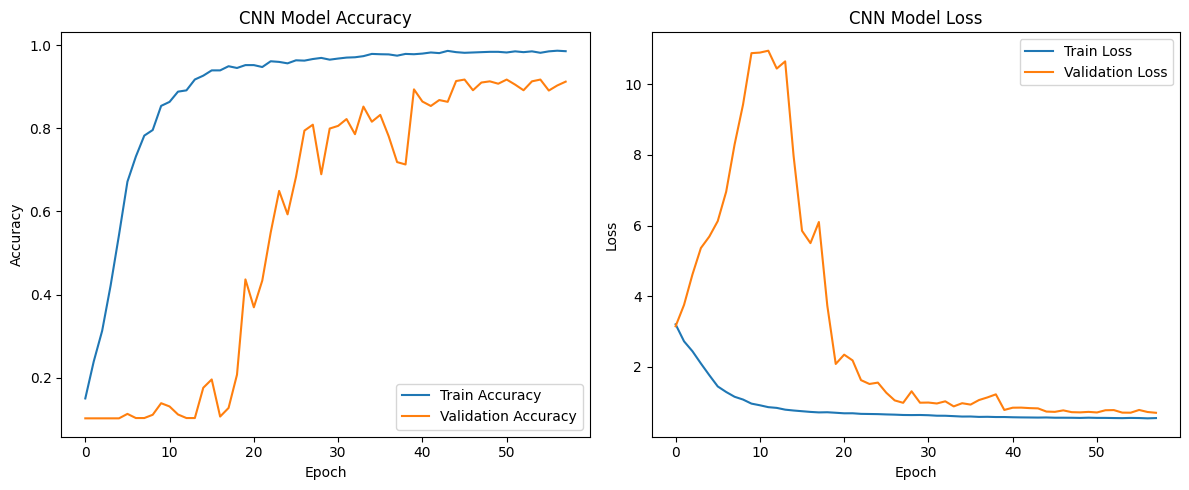

In [65]:
training_progress(history_cnn)

After I found a model that seems promising, I testest the hyperparameters in a loop to find the optimal one:

In [70]:
for batch_array_number in range(0,len(batch_size_arr)):
    for validation_array_number in range(0,len(validation_split_arr)):
        counter_for_train = counter_for_train + 1
        print([curr_model[0],int(curr_model[1][batch_array_number]),curr_model[2][validation_array_number]])
        print(f'{(100*counter_for_train)/(len(batch_size_arr)*len(validation_split_arr))}%')
        # Save the data to remake if found
        my_history.append([curr_model[0],int(curr_model[1][batch_array_number]),curr_model[2][validation_array_number]])
        # Save the data
        history.append(model_trainer(curr_model[0],int(curr_model[1][batch_array_number]),curr_model[2][validation_array_number]))
        gc.collect()

[100, 8, 0.2]
2.5%
Epoch 1/100
400/400 [==============================] - 6s 9ms/step - loss: 2.8984 - accuracy: 0.1863 - val_loss: 8.1513 - val_accuracy: 0.1112 - lr: 3.0000e-04
Epoch 2/100
400/400 [==============================] - 4s 11ms/step - loss: 2.0882 - accuracy: 0.4056 - val_loss: 24.2131 - val_accuracy: 0.1112 - lr: 3.0000e-04
Epoch 3/100
400/400 [==============================] - 4s 10ms/step - loss: 1.5164 - accuracy: 0.5938 - val_loss: 20.2035 - val_accuracy: 0.1075 - lr: 3.0000e-04
Epoch 4/100
400/400 [==============================] - 3s 9ms/step - loss: 1.0148 - accuracy: 0.7912 - val_loss: 13.3179 - val_accuracy: 0.1725 - lr: 3.0000e-04
Epoch 5/100
400/400 [==============================] - 3s 7ms/step - loss: 0.7079 - accuracy: 0.9106 - val_loss: 7.9740 - val_accuracy: 0.1900 - lr: 3.0000e-04
Epoch 6/100
400/400 [==============================] - 4s 9ms/step - loss: 0.5334 - accuracy: 0.9541 - val_loss: 7.5515 - val_accuracy: 0.2275 - lr: 3.0000e-04
Epoch 7/100
400/

[100, 8, 0.2] seem the best, so well try it:

In [81]:
best_model, history_cnn = single_model_trainer(100,8,0.2)

Epoch 1/100
400/400 [==============================] - 5s 11ms/step - loss: 2.8837 - accuracy: 0.1787 - val_loss: 3.1952 - val_accuracy: 0.1488 - lr: 3.0000e-04
Epoch 2/100
400/400 [==============================] - 4s 11ms/step - loss: 2.2900 - accuracy: 0.3131 - val_loss: 13.5822 - val_accuracy: 0.1213 - lr: 3.0000e-04
Epoch 3/100
400/400 [==============================] - 6s 14ms/step - loss: 1.6535 - accuracy: 0.5491 - val_loss: 34.0757 - val_accuracy: 0.1075 - lr: 3.0000e-04
Epoch 4/100
400/400 [==============================] - 4s 11ms/step - loss: 1.0296 - accuracy: 0.7906 - val_loss: 7.9944 - val_accuracy: 0.2250 - lr: 3.0000e-04
Epoch 5/100
397/400 [============================>.] - ETA: 0s - loss: 0.6864 - accuracy: 0.9203
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
400/400 [==============================] - 4s 9ms/step - loss: 0.6856 - accuracy: 0.9206 - val_loss: 6.8680 - val_accuracy: 0.3125 - lr: 3.0000e-04
Epoch 6/100
400/400 [============

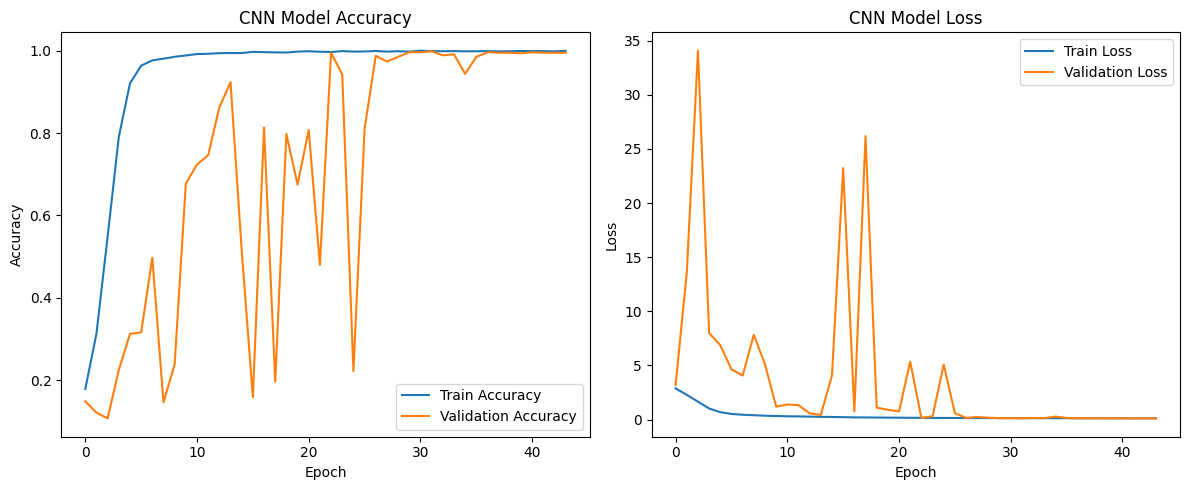

In [82]:
training_progress(history_cnn)

It "jumps" more because of the 8 size batch size, less data for every epoch can make big differences.

Although it "jumps" a lot, we can "catch" or "save" the weights of the best epoch to get the best.

Lets (for fun) test it:

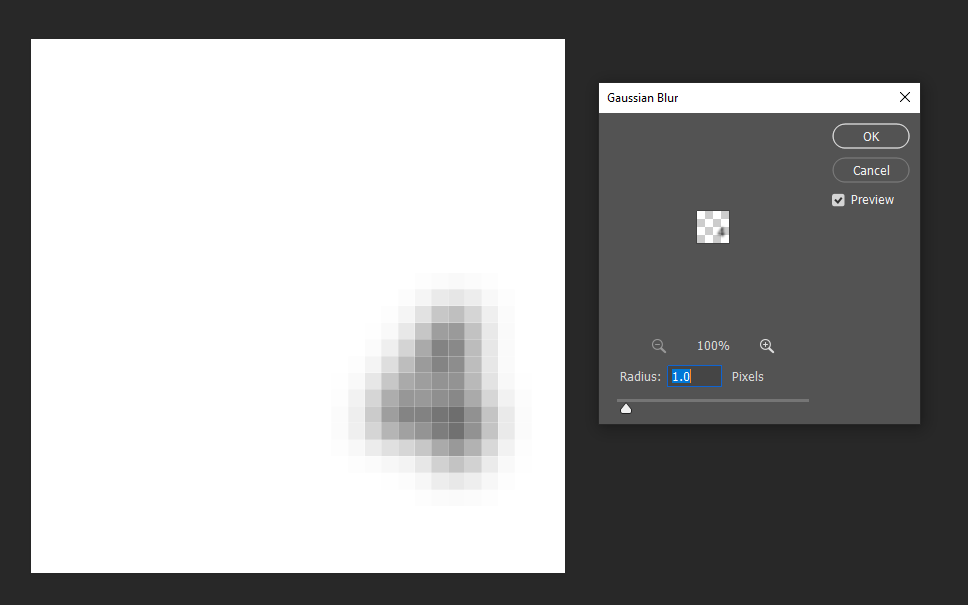

In [91]:
Image(filename='making of image_test.png')

In [88]:
image_path = 'image_test.png'

img = tf.keras.utils.load_img(image_path, target_size=(32, 32))

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

predictions = best_model.predict(img_array)

predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class] * 100

print(f"Model think the number is: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Model think the number is: 4
Confidence: 97.22%


:)